In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Device: cuda
GPU: Tesla T4
FLAN-T5 MULTI-TASK PIPELINE
Aspect + Polarity + Emotion — Joint Generation

[1/5] Loading data...
  [train] Loaded 3149 reviews
  [val] Loaded 400 reviews
  [test] Loaded 400 reviews

Example input/target pairs:
  INPUT:  It might be the best sit down food I've had in the area, so if you are going to ...
  TARGET: food, positive, admiration | place, neutral, mentioned_only

  INPUT:  Hostess was extremely accommodating when we arrived an hour early for our reserv...
  TARGET: staff, positive, admiration | miscellaneous, neutral, mentioned_only


[2/5] Training...

Loading tokenizer + model: google/flan-t5-base


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Added 19 domain tokens | Params: 222.9M

────────────────────────────────────────────────────────────
Training 8 epochs on cuda
────────────────────────────────────────────────────────────
  Epoch  1/8 | Loss: 3.8924 | Aspect: 0.6044 | A+P: 0.4079 | A+E: 0.3147 | Full: 0.2886 ★ BEST
  Epoch  2/8 | Loss: 0.6610 | Aspect: 0.7190 | A+P: 0.5533 | A+E: 0.4155 | Full: 0.4155 ★ BEST
  Epoch  3/8 | Loss: 0.4110 | Aspect: 0.7878 | A+P: 0.6172 | A+E: 0.4733 | Full: 0.4733 ★ BEST
  Epoch  4/8 | Loss: 0.3142 | Aspect: 0.8144 | A+P: 0.6440 | A+E: 0.5355 | Full: 0.5355 ★ BEST
  Epoch  5/8 | Loss: 0.2563 | Aspect: 0.8311 | A+P: 0.6862 | A+E: 0.5632 | Full: 0.5632 ★ BEST
  Epoch  6/8 | Loss: 0.2124 | Aspect: 0.8429 | A+P: 0.6962 | A+E: 0.5862 | Full: 0.5862 ★ BEST
  Epoch  7/8 | Loss: 0.1817 | Aspect: 0.8439 | A+P: 0.7026 | A+E: 0.6105 | Full: 0.6105 ★ BEST
  Epoch  8/8 | Loss: 0.1605 | Aspect: 0.8456 | A+P: 0.7102 | A+E: 0.6131 | Full: 0.6131 ★ BEST

Best epoch: 8 | Best val full-triplet F1: 0.6131



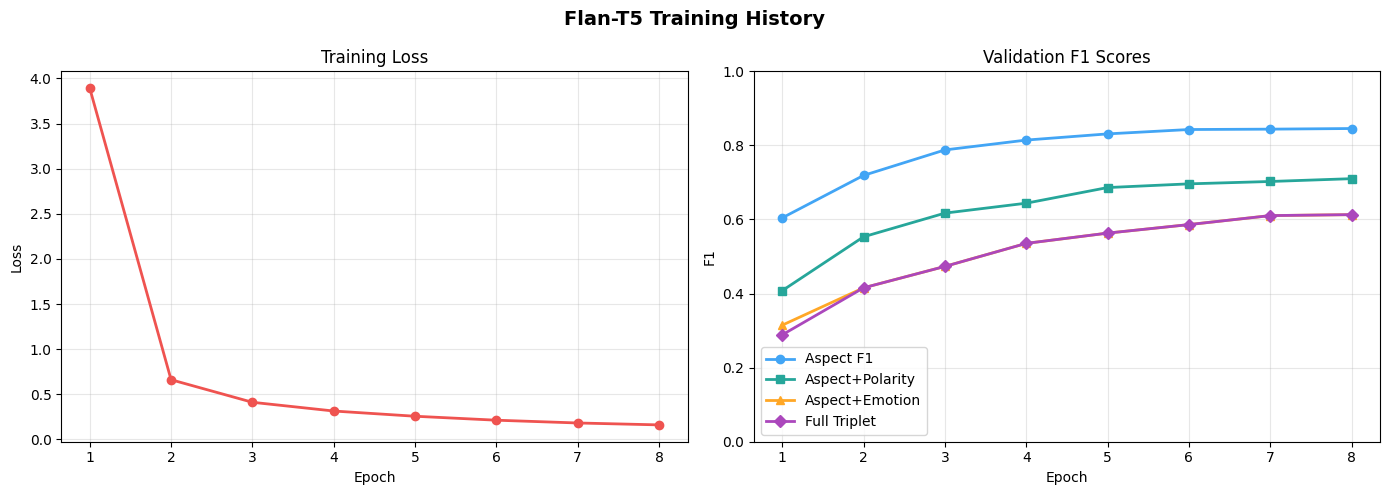

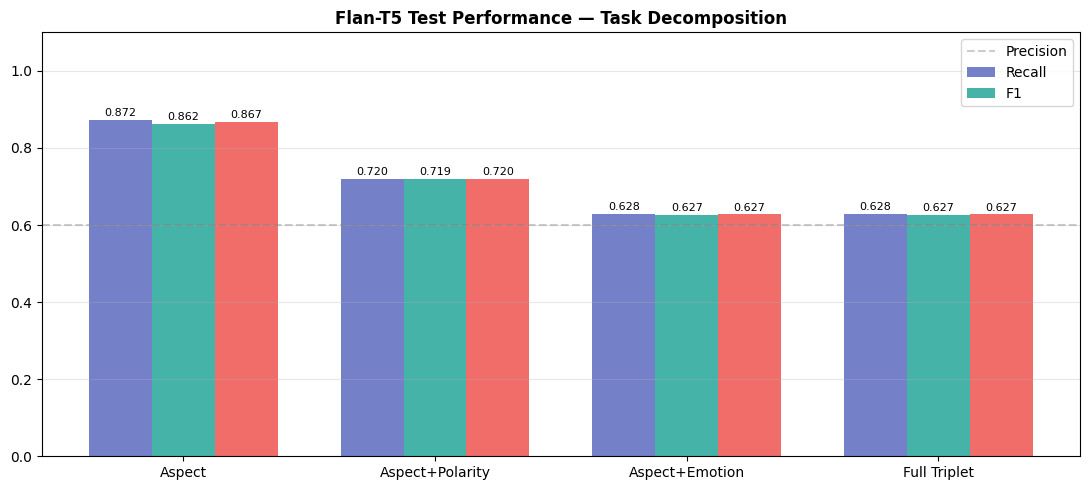

Plots saved to /content/drive/MyDrive/t5_outputs

[4/5] Saving predictions...
Saved predictions → /content/drive/MyDrive/t5_outputs/t5_predictions.csv
Exact match rate: 0.370

[5/5] FINAL SUMMARY
─────────────────────────────────────────────
  full                   F1 = 0.6274
  aspect                 F1 = 0.8672
  aspect_polarity        F1 = 0.7196
  aspect_emotion         F1 = 0.6274
─────────────────────────────────────────────
All outputs saved to: /content/drive/MyDrive/t5_outputs


In [9]:

import subprocess
subprocess.run(["pip", "install", "transformers", "sentencepiece", "torch", "-q"], check=False)
import json, os, re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.metrics import f1_score
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    T5ForConditionalGeneration,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW


MODEL_NAME   = "google/flan-t5-base"
MAX_INPUT    = 128
MAX_TARGET   = 96
BATCH_SIZE   = 16
EPOCHS       = 8
LR           = 3e-4
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
BEAM_SIZE    = 4
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"


TRAIN_PATH = "/content/drive/MyDrive/gpt_output_train.jsonl"
VAL_PATH   = "/content/drive/MyDrive/gpt_output_validation.jsonl"
TEST_PATH  = "/content/drive/MyDrive/gpt_output_test.jsonl"
OUTPUT_DIR = "/content/drive/MyDrive/t5_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VALID_ASPECTS    = {"food","staff","service","place","menu","price","ambience","miscellaneous"}
VALID_POLARITIES = {"positive","negative","neutral"}
VALID_EMOTIONS   = {
    "admiration","annoyance","disappointment","disgust",
    "gratitude","mixed_emotions","neutral","satisfaction","mentioned_only"
}

print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")



def load_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

def triplets_to_target_string(output_list):
    """
    Convert annotation list → pipe-separated string.
    [{"aspect":"food","polarity":"positive","emotion":"admiration"}]
    → "food, positive, admiration"
    """
    parts = []
    for ann in output_list:
        asp = ann.get("aspect", "").strip().lower()
        pol = ann.get("polarity", "").strip().lower()
        emo = ann.get("emotion", "").strip().lower()
        if asp and pol and emo and emo not in ("null", ""):
            parts.append(f"{asp}, {pol}, {emo}")
    return " | ".join(parts)

def target_string_to_triplets(text):
    """Parse T5 output string → list of (aspect, polarity, emotion) tuples."""
    triplets = []
    if not text or not text.strip():
        return triplets
    for part in text.split("|"):
        fields = [f.strip().lower() for f in part.strip().split(",")]
        if len(fields) >= 3:
            triplets.append((fields[0], fields[1], fields[2]))
    return triplets

def build_prompt(review_text):
    return (
        "Extract all aspect-sentiment-emotion triplets from this restaurant review. "
        "Format: aspect, polarity, emotion | aspect, polarity, emotion\n"
        f"Review: {review_text}"
    )

def load_and_format(path, split_name):
    """
    Load a .jsonl file and convert to DataFrame with prompt + target columns.
    THIS IS THE FUNCTION THAT WAS MISSING — now defined before main().
    """
    records = load_jsonl(path)
    rows = []
    for rec in records:
        text   = rec["input"].strip()
        target = triplets_to_target_string(rec["output"])
        if not target:
            continue
        rows.append({
            "text":   text,
            "target": target,
            "prompt": build_prompt(text),
            "split":  split_name,
        })
    df = pd.DataFrame(rows)
    print(f"  [{split_name}] Loaded {len(df)} reviews")
    return df



class T5EmotionDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.tokenizer = tokenizer
        self.prompts   = df["prompt"].tolist()
        self.targets   = df["target"].tolist()

    def __len__(self):
        return len(self.prompts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.prompts[idx],
            max_length=MAX_INPUT,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        dec = self.tokenizer(
            self.targets[idx],
            max_length=MAX_TARGET,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        labels = dec["input_ids"].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100  # ignore padding in loss
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         labels,
        }



def compute_triplet_f1(pred_strings, gold_strings):
    """
    4-level evaluation:
      aspect            → did the model find the right aspects?
      aspect_polarity   → aspect + polarity both correct?
      aspect_emotion    → aspect + emotion both correct?
      full              → all three fields exactly correct?
    """
    stats = defaultdict(lambda: {"tp": 0, "fp": 0, "fn": 0})

    for pred_str, gold_str in zip(pred_strings, gold_strings):
        pred_t = set(target_string_to_triplets(pred_str))
        gold_t = set(target_string_to_triplets(gold_str))

        tp = len(pred_t & gold_t)
        stats["full"]["tp"] += tp
        stats["full"]["fp"] += len(pred_t) - tp
        stats["full"]["fn"] += len(gold_t) - tp

        pa = {t[0] for t in pred_t}; ga = {t[0] for t in gold_t}
        tp = len(pa & ga)
        stats["aspect"]["tp"] += tp
        stats["aspect"]["fp"] += len(pa) - tp
        stats["aspect"]["fn"] += len(ga) - tp

        pp = {(t[0],t[1]) for t in pred_t}; gp = {(t[0],t[1]) for t in gold_t}
        tp = len(pp & gp)
        stats["aspect_polarity"]["tp"] += tp
        stats["aspect_polarity"]["fp"] += len(pp) - tp
        stats["aspect_polarity"]["fn"] += len(gp) - tp

        pe = {(t[0],t[2]) for t in pred_t}; ge = {(t[0],t[2]) for t in gold_t}
        tp = len(pe & ge)
        stats["aspect_emotion"]["tp"] += tp
        stats["aspect_emotion"]["fp"] += len(pe) - tp
        stats["aspect_emotion"]["fn"] += len(ge) - tp

    results = {}
    for key, s in stats.items():
        prec = s["tp"] / (s["tp"] + s["fp"]) if (s["tp"] + s["fp"]) > 0 else 0
        rec  = s["tp"] / (s["tp"] + s["fn"]) if (s["tp"] + s["fn"]) > 0 else 0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        results[key] = {"precision": round(prec,4), "recall": round(rec,4), "f1": round(f1,4)}
    return results

def train_flan_t5(df_train, df_val, df_test):

    print(f"\nLoading tokenizer + model: {MODEL_NAME}")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model     = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)

    special_tokens = list(VALID_ASPECTS | VALID_POLARITIES | VALID_EMOTIONS)
    num_added = tokenizer.add_tokens(special_tokens)
    model.resize_token_embeddings(len(tokenizer))
    print(f"Added {num_added} domain tokens | Params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

    train_loader = DataLoader(T5EmotionDataset(df_train, tokenizer), batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(T5EmotionDataset(df_val,   tokenizer), batch_size=BATCH_SIZE)
    test_loader  = DataLoader(T5EmotionDataset(df_test,  tokenizer), batch_size=BATCH_SIZE)

    optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    total_steps  = len(train_loader) * EPOCHS
    scheduler    = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(WARMUP_RATIO * total_steps),
        num_training_steps=total_steps,
    )

    history = {"train_loss": [], "val_full_f1": [], "val_aspect_f1": [], "val_ap_f1": [], "val_ae_f1": []}
    best_val_f1, best_test_preds, best_epoch = 0.0, None, 0

    print(f"\n{'─'*60}")
    print(f"Training {EPOCHS} epochs on {DEVICE}")
    print(f"{'─'*60}")

    for epoch in range(1, EPOCHS + 1):


        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            loss  = model(**batch).loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)


        model.eval()
        val_preds = []
        with torch.no_grad():
            for batch in val_loader:
                gen = model.generate(
                    input_ids=batch["input_ids"].to(DEVICE),
                    attention_mask=batch["attention_mask"].to(DEVICE),
                    max_new_tokens=MAX_TARGET,
                    num_beams=BEAM_SIZE,
                    early_stopping=True,
                )
                val_preds.extend(tokenizer.batch_decode(gen, skip_special_tokens=True))

        m = compute_triplet_f1(val_preds, df_val["target"].tolist())
        history["train_loss"].append(avg_loss)
        history["val_full_f1"].append(m["full"]["f1"])
        history["val_aspect_f1"].append(m["aspect"]["f1"])
        history["val_ap_f1"].append(m["aspect_polarity"]["f1"])
        history["val_ae_f1"].append(m["aspect_emotion"]["f1"])

        star = " ★ BEST" if m["full"]["f1"] > best_val_f1 else ""
        print(f"  Epoch {epoch:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | "
              f"Aspect: {m['aspect']['f1']:.4f} | A+P: {m['aspect_polarity']['f1']:.4f} | "
              f"A+E: {m['aspect_emotion']['f1']:.4f} | Full: {m['full']['f1']:.4f}{star}")

        if m["full"]["f1"] > best_val_f1:
            best_val_f1 = m["full"]["f1"]
            best_epoch  = epoch
            test_preds  = []
            with torch.no_grad():
                for batch in test_loader:
                    gen = model.generate(
                        input_ids=batch["input_ids"].to(DEVICE),
                        attention_mask=batch["attention_mask"].to(DEVICE),
                        max_new_tokens=MAX_TARGET,
                        num_beams=BEAM_SIZE,
                        early_stopping=True,
                    )
                    test_preds.extend(tokenizer.batch_decode(gen, skip_special_tokens=True))
            best_test_preds = test_preds

    print(f"\nBest epoch: {best_epoch} | Best val full-triplet F1: {best_val_f1:.4f}")


    test_metrics = compute_triplet_f1(best_test_preds, df_test["target"].tolist())
    print(f"\n{'─'*60}")
    print("FINAL TEST RESULTS")
    print(f"{'─'*60}")
    for key, vals in test_metrics.items():
        print(f"  {key:<22} F1={vals['f1']:.4f}  P={vals['precision']:.4f}  R={vals['recall']:.4f}")

    return model, tokenizer, history, test_metrics, best_test_preds



def plot_all(history, test_metrics, pred_strings, gold_strings):


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Flan-T5 Training History", fontweight="bold", fontsize=14)
    ep = range(1, len(history["train_loss"]) + 1)
    ax1.plot(ep, history["train_loss"], marker="o", color="#EF5350", linewidth=2)
    ax1.set_title("Training Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.grid(alpha=0.3)
    ax2.plot(ep, history["val_aspect_f1"], marker="o",  label="Aspect F1",       color="#42A5F5", lw=2)
    ax2.plot(ep, history["val_ap_f1"],     marker="s",  label="Aspect+Polarity", color="#26A69A", lw=2)
    ax2.plot(ep, history["val_ae_f1"],     marker="^",  label="Aspect+Emotion",  color="#FFA726", lw=2)
    ax2.plot(ep, history["val_full_f1"],   marker="D",  label="Full Triplet",    color="#AB47BC", lw=2)
    ax2.set_title("Validation F1 Scores"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("F1")
    ax2.legend(); ax2.grid(alpha=0.3); ax2.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/t5_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()


    labels = ["Aspect", "Aspect+Polarity", "Aspect+Emotion", "Full Triplet"]
    keys   = ["aspect", "aspect_polarity", "aspect_emotion", "full"]
    prec = [test_metrics[k]["precision"] for k in keys]
    rec  = [test_metrics[k]["recall"]    for k in keys]
    f1s  = [test_metrics[k]["f1"]        for k in keys]
    x, w = np.arange(len(labels)), 0.25
    fig, ax = plt.subplots(figsize=(11, 5))
    for bars, vals, label, color in [
        (ax.bar(x-w, prec, w, color="#5C6BC0", alpha=0.85), prec, "Precision", "#5C6BC0"),
        (ax.bar(x,   rec,  w, color="#26A69A", alpha=0.85), rec,  "Recall",    "#26A69A"),
        (ax.bar(x+w, f1s,  w, color="#EF5350", alpha=0.85), f1s,  "F1",        "#EF5350"),
    ]:
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.3f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0,1.1)
    ax.axhline(0.6, linestyle="--", color="gray", alpha=0.4)
    ax.set_title("Flan-T5 Test Performance — Task Decomposition", fontweight="bold")
    ax.legend(["Precision","Recall","F1"]); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/t5_f1_decomposition.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Plots saved to {OUTPUT_DIR}")



def save_predictions(pred_strings, gold_strings, df_test):
    rows = []
    for pred, gold, (_, row) in zip(pred_strings, gold_strings, df_test.iterrows()):
        pred_t = target_string_to_triplets(pred)
        gold_t = target_string_to_triplets(gold)
        rows.append({
            "review":       row["text"],
            "gold":         gold,
            "predicted":    pred,
            "exact_match":  set(pred_t) == set(gold_t),
            "num_gold":     len(gold_t),
            "num_pred":     len(pred_t),
        })
    df_out = pd.DataFrame(rows)
    path = f"{OUTPUT_DIR}/t5_predictions.csv"
    df_out.to_csv(path, index=False)
    print(f"Saved predictions → {path}")
    print(f"Exact match rate: {df_out['exact_match'].mean():.3f}")
    return df_out



def main():
    print("=" * 60)
    print("FLAN-T5 MULTI-TASK PIPELINE")
    print("Aspect + Polarity + Emotion — Joint Generation")
    print("=" * 60)


    print("\n[1/5] Loading data...")
    df_train = load_and_format(TRAIN_PATH, "train")
    df_val   = load_and_format(VAL_PATH,   "val")
    df_test  = load_and_format(TEST_PATH,  "test")

    print("\nExample input/target pairs:")
    for _, row in df_train.head(2).iterrows():
        print(f"  INPUT:  {row['text'][:80]}...")
        print(f"  TARGET: {row['target']}\n")


    print("\n[2/5] Training...")
    model, tokenizer, history, test_metrics, best_preds = train_flan_t5(df_train, df_val, df_test)


    print("\n[3/5] Plotting...")
    plot_all(history, test_metrics, best_preds, df_test["target"].tolist())


    print("\n[4/5] Saving predictions...")
    save_predictions(best_preds, df_test["target"].tolist(), df_test)


    print("\n[5/5] FINAL SUMMARY")
    print("─" * 45)
    for key, vals in test_metrics.items():
        print(f"  {key:<22} F1 = {vals['f1']:.4f}")
    print("─" * 45)
    print(f"All outputs saved to: {OUTPUT_DIR}")



main()